<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
# Import necessary libraries
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize



In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
X_covid = []
y_covid = []
for filename in os.listdir(covid_dir):
    image_path = os.path.join(covid_dir, filename)
    image = imread(image_path)  # Load the image
    image = resize(image, (256, 256))  # Resize the image to a desired size
    X_covid.append(image)
    y_covid.append(1)  # COVID-19 positive label

In [ ]:
# Load the non-COVID-19 (negative) images
X_non_covid = []
y_non_covid = []
for filename in os.listdir(non_covid_dir):
    image_path = os.path.join(non_covid_dir, filename)
    image = imread(image_path)  # Load the image
    image = resize(image, (256, 256))  # Resize the image to a desired size
    X_non_covid.append(image)
    y_non_covid.append(0)  # COVID-19 negative label

In [ ]:
# Combine the COVID-19 positive and negative data
X = np.array(X_covid + X_non_covid)
y = np.array(y_covid + y_non_covid)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Flatten the images into feature vectors
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust hyperparameters such as number of trees (n_estimators)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
#accuracy = accuracy_score(y_test, y_pred)
#recision = precision_score(y_test, y_pred)
#recall = recall_score(y_test, y_pred)
#f1 = f1_score(y_test, y_pred)

#accuracy = clf.score(X_test, y_test)
#precision, recall, f1_score, specificity = precision_recall_fscore_support(y_test, y_pred, pos_label=1, average='binary')
#tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision, recall, f1_score, support = precision_recall_fscore_support(y_test, y_pred, average='binary')
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_mat.ravel()
specificity = tn / (tn + fp)

In [ ]:
#print("Accuracy:", accuracy)
#print("Precision:", precision)
#print("Recall:", recall)
#print("F1-score:", f1)
# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1_score)
print("Specificity:", specificity)



Accuracy: 0.9689119170984456
Precision: 1.0
Recall: 0.25
F1-score: 0.4
Specificity: 1.0


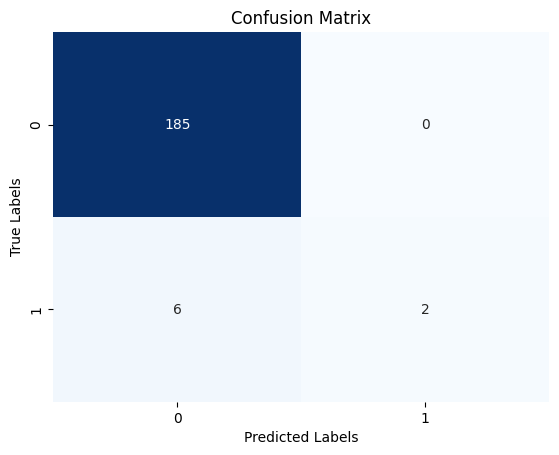

In [ ]:

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix with custom background color
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, facecolor='orange')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

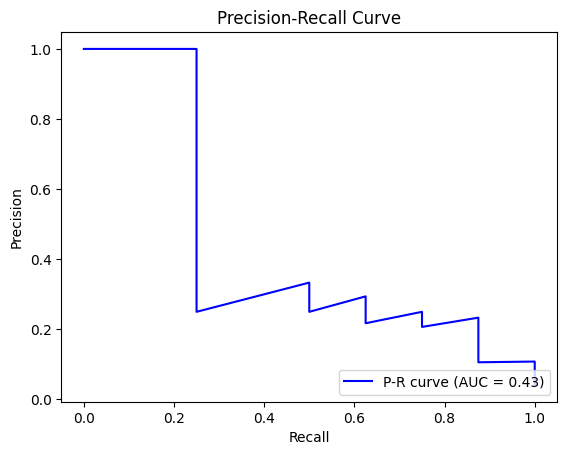

In [ ]:
# Make predictions on the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probabilities of positive class
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
area_under_curve = auc(recall, precision)

# Plot the P-R curve
plt.plot(recall, precision, color='b', label='P-R curve (AUC = %0.2f)' % area_under_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()

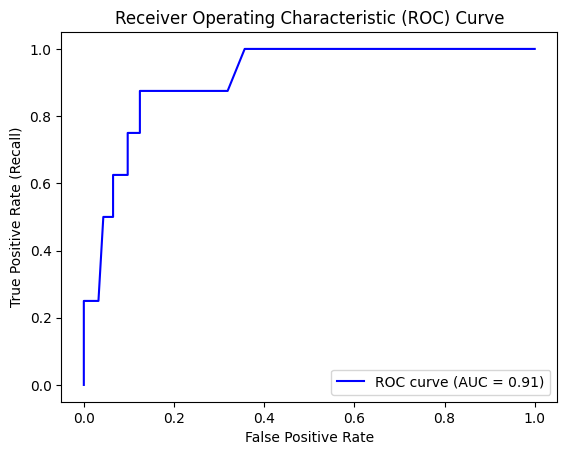

In [ ]:
# Make predictions on the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probabilities of positive class
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
area_under_curve = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, color='b', label='ROC curve (AUC = %0.2f)' % area_under_curve)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

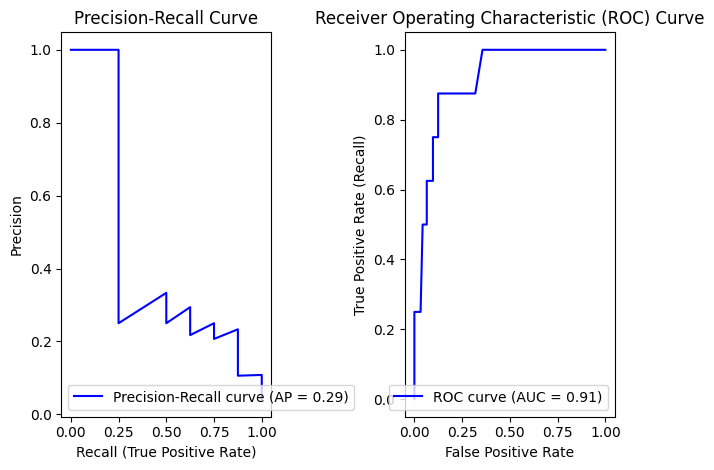

In [ ]:
# Train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probabilities of positive class

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
average_precision = np.average(precision)  # Average precision score

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
area_under_curve = auc(fpr, tpr)

# Plot Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='b', label='Precision-Recall curve (AP = %0.2f)' % average_precision)
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

# Plot ROC curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='b', label='ROC curve (AUC = %0.2f)' % area_under_curve)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Show the plots
plt.tight_layout()
plt.show()